In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# CONFIGURATION
PROCESSED_DIR = "../data/processed"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Libraries loaded. Ready to build.")

Libraries loaded. Ready to build.


In [2]:
# 1. Load Data
X = np.load(os.path.join(PROCESSED_DIR, "X.npy"))
y = np.load(os.path.join(PROCESSED_DIR, "y.npy"))
classes = np.load(os.path.join(PROCESSED_DIR, "classes.npy")) # The 7 emotions

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale Data (Standardization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Save the Scaler (WE NEED THIS FOR THE WEB APP LATER)
import joblib
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")
print("Scaler saved to ../models/scaler.pkl")

Training Shape: (9729, 193)
Testing Shape: (2433, 193)
Scaler saved to ../models/scaler.pkl


In [3]:
# Model Architecture
def build_model(input_shape):
    model = Sequential()
    
    # Input Layer + Hidden Layer 1
    model.add(Dense(512, activation='relu', input_shape=(input_shape,)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # Hidden Layer 2
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # Hidden Layer 3
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # Hidden Layer 4
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    
    # Output Layer (7 Neurons = 7 Emotions)
    model.add(Dense(len(classes), activation='softmax'))
    
    # Compile
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    
    return model

model = build_model(X_train.shape[1])
model.summary()

c:\Users\kavee\anaconda3\envs\IntWiz\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        99,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,103 (1.05 MB)

 Trainable params: 274,183 (1.05 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [4]:
# Training
# Callbacks to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,            # It will likely stop around epoch 40-50
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4102 - loss: 1.5613 - val_accuracy: 0.5183 - val_loss: 1.2269 - learning_rate: 0.0010
Epoch 2/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5106 - loss: 1.2570 - val_accuracy: 0.5467 - val_loss: 1.1531 - learning_rate: 0.0010
Epoch 3/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5407 - loss: 1.1738 - val_accuracy: 0.5668 - val_loss: 1.1142 - learning_rate: 0.0010
Epoch 4/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5603 - loss: 1.1272 - val_accuracy: 0.5824 - val_loss: 1.0813 - learning_rate: 0.0010
Epoch 5/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5743 - loss: 1.0983 - val_accuracy: 0.5750 - val_loss: 1.0693 - learning_rate: 0.0010
Epoch 6/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5819 - loss: 1.0588 - val_accuracy: 0.5935 - val_loss: 1.0435 - learning_rate: 0.0010
Epoch 7/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5932 - loss: 1.

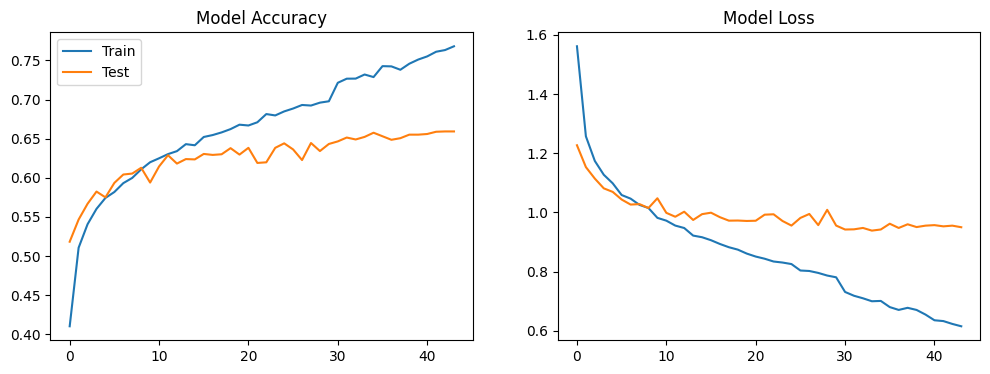

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


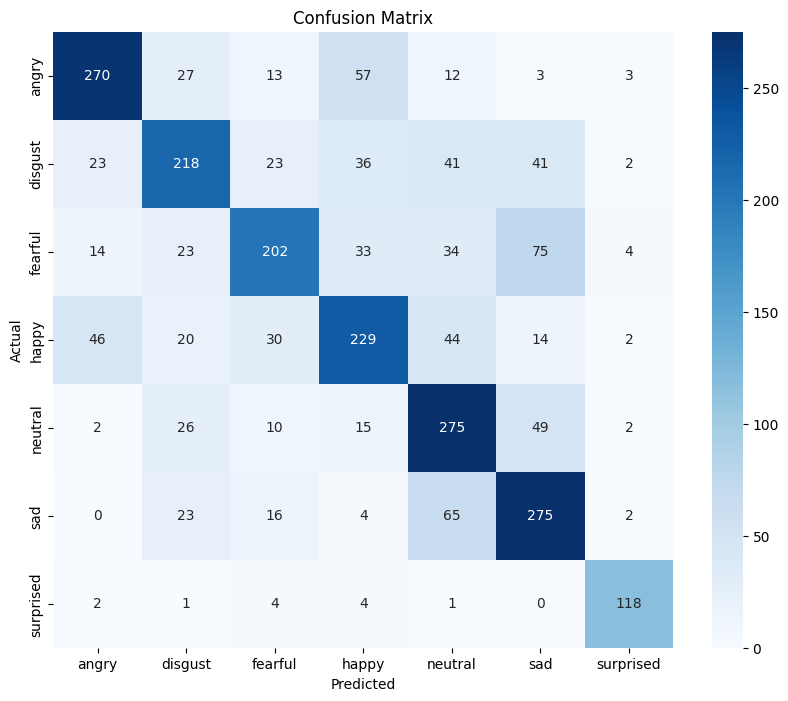


Classification Report:

              precision    recall  f1-score   support

       angry       0.76      0.70      0.73       385
     disgust       0.64      0.57      0.60       384
     fearful       0.68      0.52      0.59       385
       happy       0.61      0.59      0.60       385
     neutral       0.58      0.73      0.65       379
         sad       0.60      0.71      0.65       385
   surprised       0.89      0.91      0.90       130

    accuracy                           0.65      2433
   macro avg       0.68      0.68      0.67      2433
weighted avg       0.66      0.65      0.65      2433



In [5]:
# Evaluation
# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.title('Model Loss')
plt.show()

# Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=classes))

In [6]:
# Saving
model.save(os.path.join(MODEL_DIR, "emotion_model.h5"))
print(f"✅ Model saved to {os.path.join(MODEL_DIR, 'emotion_model.h5')}")

✅ Model saved to ../models\emotion_model.h5
